In [1]:
# from atm_data.data_utils.weather_noaa_data import *
from weather_data_processing import *
from pathlib import Path
from ast import literal_eval
import pandas as pd
import numpy as np
import functools

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
%matplotlib ipympl

from matplotlib import cm, colors
from scipy.stats import gaussian_kde as kde

from scipy.stats import pearsonr

airport = 'LGA'

In [3]:
import os
year = 2019
month = 7
start_date = "2019-07-01"
end_date = "2019-08-01" # exclusive

data_dir = Path.cwd().resolve().parent / 'data'
# weather_path = data_dir / 'noaa_lcdv2/lcd_lga_1987-2023_cleaned.parquet'
weather_path = data_dir / f'noaa_lcdv2/cleaned/lcd_{airport.lower()}_2018-2019_cleaned.parquet'
# TODO: handling in the bayesair remapped to like not have to do the "_decade" suffix
# schedule_path = data_dir / 'bts_remapped/lga_reduced_2010-2019_clean_decade/parquet/lga_reduced_2010-2019_clean_decade.parquet'
schedule_path = data_dir / f'bts_remapped/{airport}/2019/clean_daily/parquet/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_{year}_{month}_{airport}.parquet'

# start_date = "2019-07-01"
# end_date = "2019-08-01" # exclusive

# start_date = "2010-01-01"
# end_date = "2020-01-01" # exclusive



wdf = pd.read_parquet(weather_path)
sdf = pd.read_parquet(schedule_path)
sdf = (
    sdf.set_index(
        pd.DatetimeIndex(sdf['date'])
    )
    .drop(['date'], axis=1)
)


wdf = wdf.loc[(wdf.index >= start_date) & (wdf.index < end_date)]
sdf = sdf.loc[(sdf.index >= start_date) & (sdf.index < end_date)]

# mask = (sdf.scheduled_departure_time == sdf.scheduled_arrival_time)
# display(sdf.loc[mask])

for df in (wdf, sdf):
    display(df)
    display(df.dtypes)


,hourly_alitmeter_setting,hourly_dew_point_temperature,hourly_dry_bulb_temperature,hourly_precipitation,hourly_relative_humidity,hourly_visibility,hourly_wind_direction,hourly_wind_speed,hourly_wind_gust_speed,hpwt_BL,...,hsc_layer_1_height,hsc_layer_2_height,hsc_layer_3_height,hsc_total_coverage,hsc_total_amount,hsc_total_height,hsc_ceiling_coverage,hsc_ceiling_amount,hsc_ceiling_height,hourly_sky_conditions
date,,,,,,,,,,,,,,,,,,,,,
2019-07-01 00:00:00+00:00,1010.8,12.2,23.9,0.0,48.0,16.093,340.0,6.2,0.0,False,...,22.86,27.43,NaN,OVC,8.0,27.43,BKN,7.0,22.86,BKN:07-22.86 OVC:08-27.43
2019-07-01 01:00:00+00:00,1011.2,12.2,22.8,0.0,51.0,16.093,330.0,5.7,0.0,False,...,30.48,NaN,NaN,SCT,4.0,30.48,,0.0,inf,SCT:04-30.48
2019-07-01 02:00:00+00:00,1011.5,12.2,22.2,0.0,53.0,16.093,330.0,6.2,0.0,False,...,NaN,NaN,NaN,,0.0,inf,,0.0,inf,
2019-07-01 03:00:00+00:00,1011.5,12.2,21.7,0.0,55.0,16.093,330.0,5.1,0.0,False,...,inf,NaN,NaN,CLR,0.0,inf,,0.0,inf,CLR:00-inf
2019-07-01 04:00:00+00:00,1011.9,12.2,21.1,0.0,57.0,16.093,330.0,4.6,0.0,False,...,NaN,NaN,NaN,,0.0,inf,,0.0,inf,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-31 19:00:00+00:00,1016.6,19.4,22.2,3.3,84.0,1.609,270.0,4.1,0.0,False,...,8.53,15.24,NaN,OVC,8.0,15.24,BKN,7.0,8.53,BKN:07-8.53 OVC:08-15.24
2019-07-31 20:00:00+00:00,1016.3,20.6,22.8,2.8,87.0,16.093,50.0,6.2,0.0,False,...,9.75,21.34,33.53,OVC,8.0,33.53,BKN,7.0,21.34,SCT:04-9.75 BKN:07-21.34 OVC:08-33.53
2019-07-31 21:00:00+00:00,1015.9,19.4,23.3,0.0,79.0,16.093,40.0,3.1,0.0,False,...,14.02,21.34,36.58,BKN,7.0,36.58,BKN,7.0,36.58,FEW:02-14.02 SCT:04-21.34 BKN:07-36.58


hourly_alitmeter_setting         float64
hourly_dew_point_temperature     float64
hourly_dry_bulb_temperature      float64
hourly_precipitation             float64
hourly_relative_humidity         float64
hourly_visibility                float64
hourly_wind_direction            float64
hourly_wind_speed                float64
hourly_wind_gust_speed           float64
hpwt_BL                          boolean
hpwt_BLSN                        boolean
hpwt_BR                          boolean
hpwt_DZ                          boolean
hpwt_FG                          boolean
hpwt_FU                          boolean
hpwt_FZDZ                        boolean
hpwt_FZFG                        boolean
hpwt_FZRA                        boolean
hpwt_GS                          boolean
hpwt_HAIL                        boolean
hpwt_HZ                          boolean
hpwt_PL                          boolean
hpwt_RA                          boolean
hpwt_SN                          boolean
hpwt_SQ         

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,cancelled,cancellation_code,diverted,diverted_reached_destination,diverted_airport_landings
date,,,,,,,,,,,,,,,,,,,,,
2019-07-01,2019,3,7,1,1,2019-07-01,AA,19805,AA,N952UW,...,0.000000,0.000000,0.25,0.0,0.000000,False,Z,False,NaN,0
2019-07-01,2019,3,7,1,1,2019-07-01,AA,19805,AA,N990NN,...,0.000000,0.000000,0.00,0.0,0.000000,False,Z,False,NaN,0
2019-07-01,2019,3,7,1,1,2019-07-01,MQ,20398,MQ,N851AE,...,0.000000,0.000000,0.00,0.0,0.000000,False,Z,False,NaN,0
2019-07-01,2019,3,7,1,1,2019-07-01,YX,20452,YX,N115HQ,...,0.000000,0.000000,0.00,0.0,0.000000,False,Z,False,NaN,0
2019-07-01,2019,3,7,1,1,2019-07-01,MQ,20398,MQ,N836AE,...,0.000000,0.000000,0.00,0.0,0.000000,False,Z,False,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-31,2019,3,7,31,3,2019-07-31,DL,19790,DL,N102DU,...,0.166667,0.000000,0.90,0.0,1.966667,False,Z,False,NaN,0
2019-07-31,2019,3,7,31,3,2019-07-31,OO,20304,OO,N277SY,...,0.000000,0.000000,0.00,0.0,0.000000,False,Z,False,NaN,0
2019-07-31,2019,3,7,31,3,2019-07-31,AA,19805,AA,N839NN,...,0.000000,0.000000,0.15,0.0,0.700000,False,Z,False,NaN,0


Year                               int16
Quarter                            int16
Month                              int16
DayofMonth                         int16
DayOfWeek                          int16
                                  ...   
cancelled                           bool
cancellation_code               category
diverted                            bool
diverted_reached_destination     float64
diverted_airport_landings          int16
Length: 132, dtype: object

In [4]:
# TODO: some stats
# mask = (sdf.origin_airport == 'LGA')
# mask = (sdf.destination_airport == 'LGA')
# mask = (sdf.scheduled_departure_time == sdf.scheduled_arrival_time)
# display(sdf.loc[mask, ["scheduled_departure_time", "scheduled_arrival_time"]])
# display(sdf.loc[mask])
# uhh ok i guess it wasn't an sisue

sdf['scheduled_event_time'] = sdf.scheduled_departure_time.copy()
mask = sdf.destination_airport == airport
sdf.loc[mask, "scheduled_event_time"] = sdf.loc[mask, "scheduled_arrival_time"]

sdf['actual_event_time'] = sdf.actual_departure_time.copy()
mask = sdf.destination_airport == airport
sdf.loc[mask, "actual_event_time"] = sdf.loc[mask, "actual_arrival_time"]

sdf['scheduled_event_datetime'] = sdf.index + pd.to_timedelta(sdf.scheduled_event_time, unit='H')
sdf['actual_event_datetime'] = sdf.index + pd.to_timedelta(sdf.actual_event_time, unit='H')

sdf['event_delay'] = sdf.actual_event_time - sdf.scheduled_event_time
sdf.loc[sdf.cancelled | sdf.diverted, 'event_delay'] = 0.0

sdf['event_delay_relu'] = sdf.event_delay.clip(lower=0.0)
sdf['arrival_delay_relu'] = sdf.arrival_delay.clip(lower=0.0)
sdf['departure_delay_relu'] = sdf.departure_delay.clip(lower=0.0)

display(sdf)

C:\Users\micah\AppData\Local\Temp\ipykernel_64088\3873190144.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  sdf['scheduled_event_datetime'] = sdf.index + pd.to_timedelta(sdf.scheduled_event_time, unit='H')
C:\Users\micah\AppData\Local\Temp\ipykernel_64088\3873190144.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  sdf['actual_event_datetime'] = sdf.index + pd.to_timedelta(sdf.actual_event_time, unit='H')


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,diverted_reached_destination,diverted_airport_landings,scheduled_event_time,actual_event_time,scheduled_event_datetime,actual_event_datetime,event_delay,event_delay_relu,arrival_delay_relu,departure_delay_relu
date,,,,,,,,,,,,,,,,,,,,,
2019-07-01,2019,3,7,1,1,2019-07-01,AA,19805,AA,N952UW,...,NaN,0,7.166667,7.416667,2019-07-01 07:10:00.000000001,2019-07-01 07:25:00.000000001,0.250000,0.250000,0.250000,0.000000
2019-07-01,2019,3,7,1,1,2019-07-01,AA,19805,AA,N990NN,...,NaN,0,5.666667,5.600000,2019-07-01 05:40:00.000000001,2019-07-01 05:36:00.000000000,-0.066667,0.000000,0.000000,0.000000
2019-07-01,2019,3,7,1,1,2019-07-01,MQ,20398,MQ,N851AE,...,NaN,0,7.100000,6.950000,2019-07-01 07:06:00.000000000,2019-07-01 06:57:00.000000000,-0.150000,0.000000,0.000000,0.000000
2019-07-01,2019,3,7,1,1,2019-07-01,YX,20452,YX,N115HQ,...,NaN,0,5.750000,5.766667,2019-07-01 05:45:00.000000000,2019-07-01 05:46:00.000000001,0.016667,0.016667,0.000000,0.016667
2019-07-01,2019,3,7,1,1,2019-07-01,MQ,20398,MQ,N836AE,...,NaN,0,7.183333,6.733333,2019-07-01 07:10:59.999999998,2019-07-01 06:43:59.999999998,-0.450000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-31,2019,3,7,31,3,2019-07-31,DL,19790,DL,N102DU,...,NaN,0,21.983333,24.116667,2019-07-31 21:58:59.999999998,2019-08-01 00:07:00.000000001,2.133333,2.133333,3.033333,2.133333
2019-07-31,2019,3,7,31,3,2019-07-31,OO,20304,OO,N277SY,...,NaN,0,21.983333,21.950000,2019-07-31 21:58:59.999999998,2019-07-31 21:57:00.000000000,-0.033333,0.000000,0.000000,0.000000
2019-07-31,2019,3,7,31,3,2019-07-31,AA,19805,AA,N839NN,...,NaN,0,22.000000,22.700000,2019-07-31 22:00:00.000000000,2019-07-31 22:42:00.000000000,0.700000,0.700000,0.850000,0.700000


In [5]:
def plot_condition_and_delays(
    type, 
    # these should be aligned time-wise
    conditions,
    dep_delays,
    arr_delays,
    start,
    end,
    condition_aggregation,
    delay_aggregation,
    colors = ('blue', 'red', 'orange'),
    figsize = (8,8)
):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    ax2 = ax.twinx()

    ax.plot(conditions, color=colors[0], label=f'{type}')
    ax2.plot(dep_delays, color=colors[1], label='departure delay')
    ax2.plot(arr_delays, color=colors[2], label='arrival delay')

    add_decorations(fig, ax, ax2, type, condition_aggregation, delay_aggregation, start, end, 'horizontal')

    return fig


def scatter_condition_and_delays(
    type, 
    # these should be aligned time-wise
    conditions,
    dep_delays,
    arr_delays,
    start,
    end,
    condition_aggregation,
    delay_aggregation,
    colors = ('blue', 'red', 'orange'),
    figsize = (8,8)
):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    def plot_scatter_and_trend(ax, x, y, color, linestyle='-', marker='.', label=None, d=1):        
        ax.scatter(x, y, color=c, marker=marker, label=label)
        z = np.polyfit(x, y, deg=d)
        p = np.poly1d(z)
        plt.plot(x, p(x), color=color, linestyle=linestyle)

    x = conditions
    for y, c, l in ((dep_delays, colors[1], 'departure'), (arr_delays, colors[2], 'arrival')):
        r, _ = pearsonr(x, y)
        plot_scatter_and_trend(ax, x.to_numpy(), y.to_numpy(), c, label=f'{l}, ρ={r:.03f}')

    add_decorations(fig, ax, None, type, condition_aggregation, delay_aggregation, start, end, 'vertical')

    return fig


def add_decorations(
    fig, ax, ax2, type, condition_aggregation, delay_aggregation, start, end, side
):
    if side == 'horizontal':
        set_condition_label = ax.set_ylabel
        set_delay_label = ax2.set_ylabel
        ax.set_ylim(bottom=0)
        add_flight_rule_regions(ax, type, 'horizontal')
        ax.set_xlabel('date')
        fig.legend()
    elif side == 'vertical':
        set_condition_label = ax.set_xlabel
        set_delay_label = ax.set_ylabel
        ax.set_xlim(left=0)
        add_flight_rule_regions(ax, type, 'vertical')
        ax.legend()
    else:
        raise ValueError

    set_condition_label(
        f"{type} {'(ft)' if type == 'ceiling' else '(mi)'} -- lower is worse -- [{condition_aggregation}]"
    )
    set_delay_label(f'delay (hrs) -- higher is worse -- [{delay_aggregation}]')

    ax.set_title(
        f'{type} and delays between {start} and {end}'
    )


def add_flight_rule_regions(
    ax, 
    type,
    side, 
    thresholds=None,
    colors=None,
    alpha=.2,
    linestyle='--',
):
    if side == 'horizontal':
        add_line = ax.axhline
        add_span = ax.axhspan
        cmin, cmax = ax.get_ylim()            
    elif side == 'vertical':
        add_line = ax.axvline
        add_span = ax.axvspan
        cmin, cmax = ax.get_xlim()
    else:
        raise ValueError('type must be horizontal or vertical :(')

    if thresholds is None:
        if type == 'ceiling':
            thresholds = [500, 1000, 3200]
        elif type == 'visibility':
            thresholds = [1, 3, 4]
        else:
            raise ValueError('type must be ceiling or visibility')
    else:
        assert len(thresholds) == 3 # TODO: generalize??
        
    if colors is None:
        colors = ['darkred', 'red', 'yellow', 'lightgreen']
    else:
        assert len(colors) == 4 # TODO: generalize??

    for threshold, color in zip(thresholds, colors):
        add_line(threshold, color=color, linestyle=linestyle)
    
    span_lo = [cmin] + thresholds
    span_hi = thresholds + [cmax]

    labels = [
        'LIFR (low IFR)',
        'IFR (instrument)',
        'MVFR (marginal)',
        'VFR (visual)',
    ]
    
    for lo, hi, color, label in zip(span_lo, span_hi, colors, labels):
        add_span(lo, hi, facecolor=color, alpha=alpha, label=label)



In [6]:
# TODO: maybe we can auto-generate a description??
def process_series(
    s,
    *argv,
):
    # print(argv)
    for arg in argv:
        # print(arg, type(arg))
        if isinstance(arg, str):
            action = arg
            if action == 'no_inf':
                s = s.loc[~s.isin([np.inf])]
            elif action == 'no_nan':
                s = s.loc[~s.isin([np.nan])]
            elif action == 'inverse':
                s = 1.0 / s
        elif isinstance(arg, (list, tuple, np.ndarray)):
            action = arg[0]
            if action == 'scale':
                s = s * arg[1]
            elif action == 'clip':
                s = s.clip(lower=arg[1], upper=arg[2])
            elif action == 'filter_index':
                s = s.loc[(arg[1] <= s.index) & (s.index < arg[2])]
            elif action == 'apply_func':
                s = s.apply(arg[1])
            elif action == 'apply_func_vec':
                s = arg[1](s)
            else:
                sg = s.groupby(pd.Grouper(freq=arg[1]))
                if action == 'mean':
                    s = sg.mean()
                elif action == 'min':
                    s = sg.min()
                elif action == 'max':
                    s = sg.max()
                elif action == 'size':
                    s = sg.size()
                else:
                    raise ValueError(f'invalid step: {arg}')
    return s

freq = '1D'
ceiling = wdf.hsc_ceiling_height

process_ceiling = functools.partial(process_series, ceiling)

ch_daily_finite_mean = process_ceiling(
    'no_inf', 'no_nan', ('mean', freq)
)

ch_daily_min = process_ceiling(
    'min'
)

ch_daily_inverse_mean = process_ceiling(
    'inverse', ('mean', freq)
)
ch_daily_harmonic_mean = process_series(
    ch_daily_inverse_mean, 'inverse'
)

ch_hourly_clipped = process_ceiling(
    ('clip', .5, 64)
)

ch_daily_clipped_mean = process_series(
    ch_hourly_clipped, ('mean', freq)
)

ch_daily_clipped_inverse_mean = process_series(
    ch_hourly_clipped, ('inverse'), ('mean', freq)  
)

ch_daily_clipped_harmonic_mean = process_series(
    ch_daily_clipped_inverse_mean, ('inverse')
)

# display(ch_daily_clipped_harmonic_mean.nsmallest(5))

sdf_outgoing = sdf.loc[sdf.origin_airport == airport]
sdf_incoming = sdf.loc[sdf.destination_airport == airport]

dep_delay_daily = process_series(
    sdf_outgoing.departure_delay_relu, ('mean', freq)
)
arr_delay_daily = process_series(
    sdf_incoming.arrival_delay_relu, ('mean', freq)
)


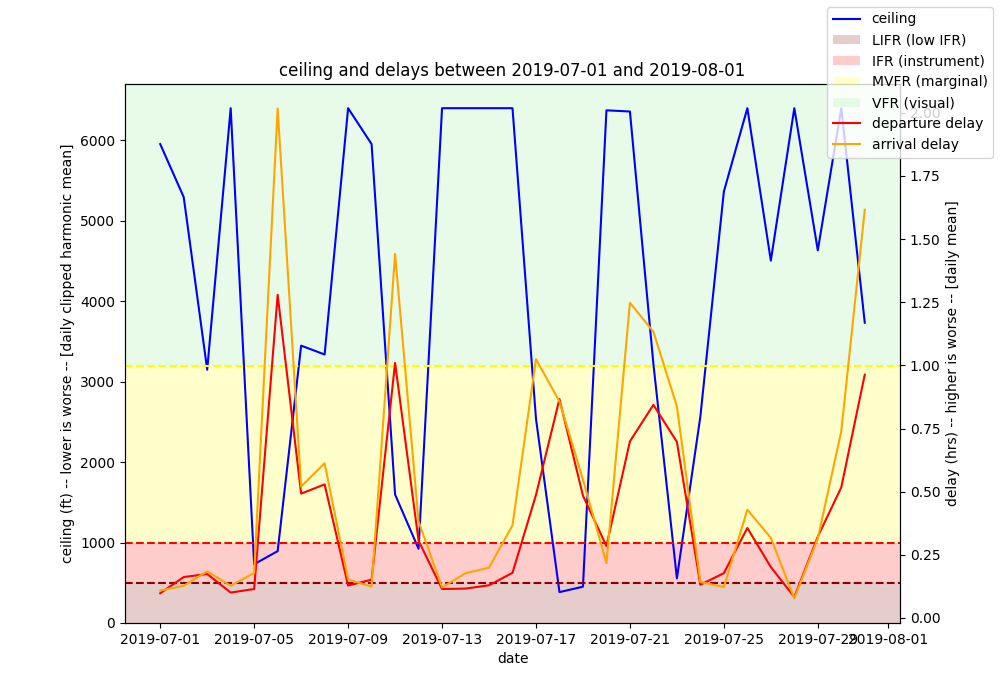

In [7]:
# show that we can do these from scratch easily!
# though maybe kinda silly and not much benefit over pandas methods
freq = '1D'
start = '2019-07-01'
end = '2019-08-01'

processed_ceiling = process_series(
    wdf.hsc_ceiling_height,
    ('filter_index', start, end),
    ('clip', .5, 64), 
    ('scale', 100), 
    ('inverse'), 
    ('mean', freq), 
    ('inverse'),
)
v = processed_ceiling

d = process_series(
    sdf_outgoing.departure_delay_relu,
    ('filter_index', start, end),
    ('mean', freq),
)

a = process_series(
    sdf_incoming.arrival_delay_relu,
    ('filter_index', start, end),
    ('mean', freq),
)

fig = plot_condition_and_delays(
    type='ceiling', 
    conditions=v,
    dep_delays=d,
    arr_delays=a,
    start=start,
    end=end,
    condition_aggregation='daily clipped harmonic mean',
    delay_aggregation='daily mean',
    figsize=(10,7)
)